# DSL_PROJ
Converted from R Markdown

## Load dataset and preview

In [2]:
import pandas as pd

# Load the dataset
data = pd.read_csv("../Datasets_and_maps/merged.csv", encoding="utf-8")
data.head()


,Unnamed: 0,Country,Region,Income group,Renewable Energy score,Total_Capacity_MW,Renewable_Capacity_MW,Renewable_Share
0,0,Afghanistan,South Asia,Low income,26.934385,300.550,258.55,0.860256
1,1,Algeria,Middle East & North Africa,Upper middle income,51.101032,15873.800,694.80,0.043770
2,2,Angola,Sub-Saharan Africa,Upper middle income,17.361071,1071.180,770.60,0.719394
3,3,Argentina,Latin America & Caribbean,High income,52.781026,32913.079,10727.09,0.325922
4,4,Armenia,Europe & Central Asia,Lower middle income,63.071833,3271.000,965.00,0.295017


## Scatter Plot by Income Group

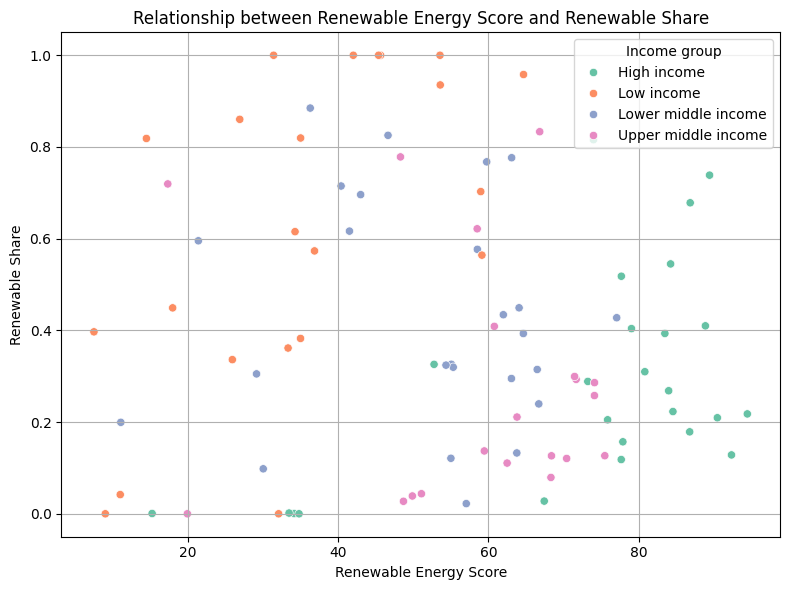

In [5]:
import seaborn as sns
import matplotlib.pyplot as plt

# Ensure 'Income.group' is categorical
data['Income group'] = data['Income group'].astype('category')

# Plot
plt.figure(figsize=(8, 6))
sns.scatterplot(data=data, x='Renewable Energy score', y='Renewable_Share', hue='Income group', palette='Set2')
plt.title('Relationship between Renewable Energy Score and Renewable Share')
plt.xlabel('Renewable Energy Score')
plt.ylabel('Renewable Share')
plt.grid(True)
plt.tight_layout()
plt.show()


## Linear Regression and Residual Analysis by Income Group

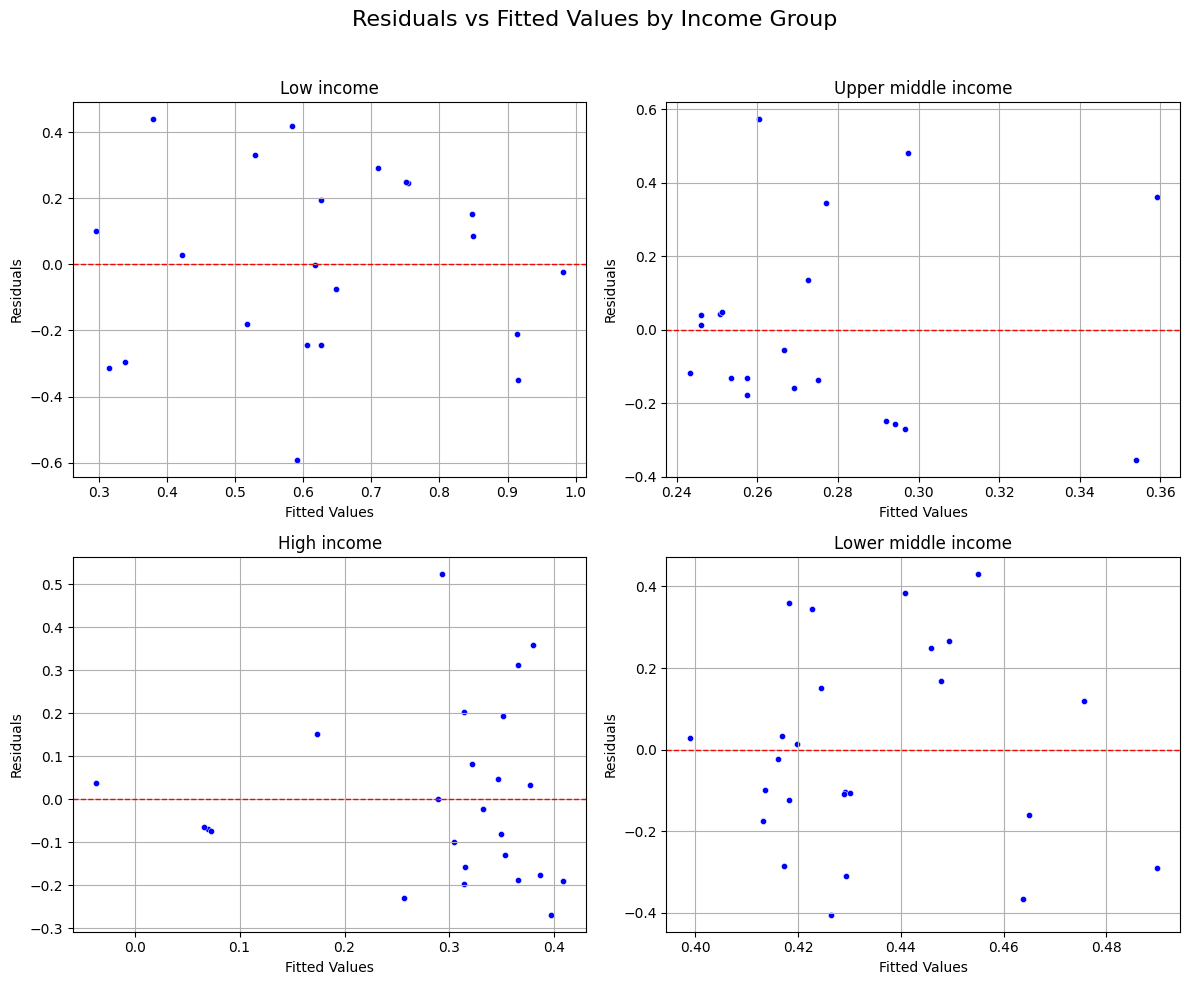

In [8]:
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

groups = data['Income group'].unique()
n_groups = len(groups)

fig, axes = plt.subplots(2, 2, figsize=(12, 10), sharex=False, sharey=False)
axes = axes.flatten()

for i, group in enumerate(groups):
    subset = data[data['Income group'] == group]
    X = sm.add_constant(subset['Renewable Energy score'])
    y = subset['Renewable_Share']
    model = sm.OLS(y, X).fit()

    fitted_vals = model.fittedvalues
    residuals = model.resid

    sns.scatterplot(x=fitted_vals, y=residuals, ax=axes[i], s=20, color="blue")
    axes[i].axhline(0, color='red', lw=1, linestyle='--')
    axes[i].set_title(f"{group}")
    axes[i].set_xlabel("Fitted Values")
    axes[i].set_ylabel("Residuals")
    axes[i].grid(True)

plt.suptitle("Residuals vs Fitted Values by Income Group", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()
